## Run Simulation

In [1]:
%load_ext autoreload
%autoreload 2

Loaded: LOS Problem | Animate: True
Simulating 2000 steps...
Target Reached! Stopping at T=8.74s


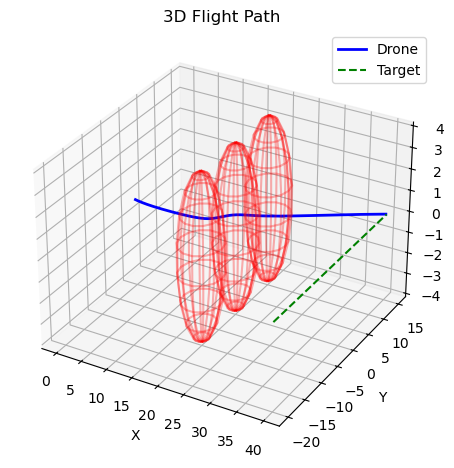

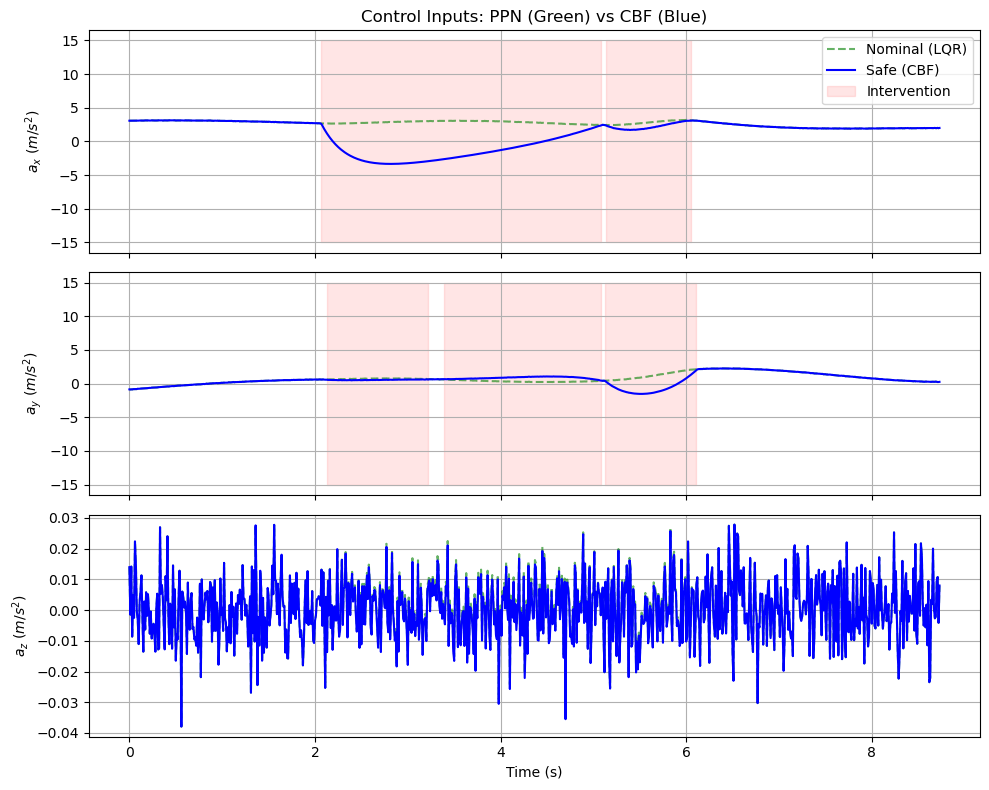

In [3]:
import numpy as np
import plotly.graph_objects as go
import matplotlib.pyplot as plt

from dynamics import DroneDynamics
from guidance import PPNGuidance
from safety_filter import SafetyFilter
import scenarios


def plot_static_results(drone_path, target_path, obstacles, u_nom_hist, u_safe_hist, time_hist):
    """
    Generates two figures:
    1. 3D Flight Path (Static)
    2. Control Input Comparison (Nominal vs Safe)
    """
    # --- FIGURE 1: 3D TRAJECTORY ---
    fig = plt.figure(figsize=(12, 6))
    
    # Subplot 1: 3D View
    ax = fig.add_subplot(1, 2, 1, projection='3d')
    path = np.array(drone_path)
    t_path = np.array(target_path)

    ax.plot(path[:, 0], path[:, 1], path[:, 2], label='Drone', color='blue', linewidth=2)
    ax.plot(t_path[:, 0], t_path[:, 1], t_path[:, 2], label='Target', color='green', linestyle='--')
    
    # Draw Obstacles
    u, v = np.mgrid[0:2*np.pi:15j, 0:np.pi:10j]
    for obs in obstacles:
        x = obs.center[0] + obs.radius * np.cos(u) * np.sin(v)
        y = obs.center[1] + obs.radius * np.sin(u) * np.sin(v)
        z = obs.center[2] + obs.radius * np.cos(v)
        ax.plot_wireframe(x, y, z, color='red', alpha=0.3)

    ax.set_title("3D Flight Path")
    ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
    ax.legend()

    # --- FIGURE 2: CONTROL INPUTS ---
    # Subplot 2, 3, 4: Acceleration X, Y, Z
    u_nom = np.array(u_nom_hist)
    u_safe = np.array(u_safe_hist)
    t = np.array(time_hist)
    
    fig2, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
    labels = ['$a_x$', '$a_y$', '$a_z$']
    
    for i in range(3):
        axs[i].plot(t, u_nom[:, i], 'g--', label='Nominal (LQR)', alpha=0.6)
        axs[i].plot(t, u_safe[:, i], 'b-', label='Safe (CBF)')
        
        # Highlight Intervention
        diff = np.abs(u_nom[:, i] - u_safe[:, i])
        mask = diff > 0.05
        if np.any(mask):
            axs[i].fill_between(t, -15, 15, where=mask, color='red', alpha=0.1, label='Intervention')
            
        axs[i].set_ylabel(f"{labels[i]} ($m/s^2$)")
        axs[i].grid(True)
    
    axs[0].set_title("Control Inputs: PPN (Green) vs CBF (Blue)")
    axs[0].legend(loc='upper right')
    axs[2].set_xlabel("Time (s)")
    
    plt.tight_layout()
    plt.show()


def animate_plotly(path, target_path, obs_history, mission, dt, static_only=False):
    
    total_frames = len(path)
    stride = max(1, total_frames // 150)
    #stride = 5
    fig = go.Figure()

    # --- HELPER: Sphere Geometry ---
    # Reduced resolution slightly (15->10, 10->8) for better performance with many objects
    def get_sphere_data(center, radius):
        u = np.linspace(0, 2 * np.pi, 10) 
        v = np.linspace(0, np.pi, 8)
        x = center[0] + radius * np.outer(np.cos(u), np.sin(v))
        y = center[1] + radius * np.outer(np.sin(u), np.sin(v))
        z = center[2] + radius * np.outer(np.ones(np.size(u)), np.cos(v))
        return x, y, z

    # --- 1. SETUP TRACES ---
    # We must add ALL traces to the figure first.
    # Order matters: [Drone Path, Target Path, Drone, Target, Obs 0, Obs 1, ... Obs N]
    
    # Trace 0: Drone Path (Background)
    fig.add_trace(go.Scatter3d(
        x=path[:, 0], y=path[:, 1], z=path[:, 2],
        mode='lines', line=dict(color='blue', width=4),
        name='Drone Path', opacity=0.2
    ))

    # Trace 1: Target Path (Background)
    fig.add_trace(go.Scatter3d(
        x=target_path[:, 0], y=target_path[:, 1], z=target_path[:, 2],
        mode='lines', line=dict(color='green', width=4, dash='dash'),
        name='Target Path', opacity=0.2
    ))

    # Trace 2: Drone (Actor)
    fig.add_trace(go.Scatter3d(
        x=[path[0, 0]], y=[path[0, 1]], z=[path[0, 2]],
        mode='markers', marker=dict(color='blue', size=6),
        name='Drone'
    ))

    # Trace 3: Target (Actor)
    fig.add_trace(go.Scatter3d(
        x=[target_path[0, 0]], y=[target_path[0, 1]], z=[target_path[0, 2]],
        mode='markers', marker=dict(color='green', size=8, symbol='diamond'),
        name='Target'
    ))

    # Traces 4+: Obstacles
    # We need to know which obstacles move to optimize the animation loop
    dynamic_obs_indices = []
    
    obs_start = obs_history[0]
    for i, obs in enumerate(mission.obstacles):
        x_s, y_s, z_s = get_sphere_data(obs_start[i], obs.radius)
        fig.add_trace(go.Surface(
            x=x_s, y=y_s, z=z_s,
            colorscale=[[0, 'red'], [1, 'red']], showscale=False, opacity=0.5,
            name=f'Obs {i}'
        ))
        
        # Check if this specific obstacle has velocity
        if np.linalg.norm(obs.velocity) > 0:
            dynamic_obs_indices.append(i)

    # --- 2. CALCULATE BOUNDS ---
    all_x = np.concatenate([path[:,0], target_path[:,0]])
    all_y = np.concatenate([path[:,1], target_path[:,1]])
    all_z = np.concatenate([path[:,2], target_path[:,2]])
    pad = 2.0
    x_range = [np.min(all_x) - pad, np.max(all_x) + pad]
    y_range = [np.min(all_y) - pad, np.max(all_y) + pad]
    z_range = [min(0, np.min(all_z)) - 1.0, np.max(all_z) + pad]

    # --- 3. ANIMATION FRAMES ---
    frames = []
    
    # Calculate Plotly Trace Indices
    # Trace 0,1 are paths. Trace 2 is Drone. Trace 3 is Target. Trace 4 starts obstacles.
    trace_idx_drone = 2
    trace_idx_target = 3
    base_obs_idx = 4
    
    # We only want to update traces that actually move
    traces_to_update = [trace_idx_drone, trace_idx_target]
    for local_i in dynamic_obs_indices:
        traces_to_update.append(base_obs_idx + local_i)

    for k in range(0, total_frames, stride):
        frame_data = []
        
        # Update Drone
        drone_pos = path[k]
        frame_data.append(go.Scatter3d(x=[drone_pos[0]], y=[drone_pos[1]], z=[drone_pos[2]]))
        
        # Update Target
        target_pos = target_path[k]
        frame_data.append(go.Scatter3d(x=[target_pos[0]], y=[target_pos[1]], z=[target_pos[2]]))
        
        # Update ONLY Dynamic Obstacles
        current_obs = obs_history[k]
        for local_i in dynamic_obs_indices:
            # We only generate geometry for obstacles that moved
            radius = mission.obstacles[local_i].radius
            x_new, y_new, z_new = get_sphere_data(current_obs[local_i], radius)
            frame_data.append(go.Surface(x=x_new, y=y_new, z=z_new))

        frames.append(go.Frame(data=frame_data, traces=traces_to_update, name=str(k)))

    fig.frames = frames

    # --- 4. FINAL LAYOUT ---
    fig.update_layout(
        width=1000, height=800,
        title=f"Sim: {mission.name} (Optimized View)",
        scene=dict(
            xaxis=dict(range=x_range, title="X", autorange=False),
            yaxis=dict(range=y_range, title="Y", autorange=False),
            zaxis=dict(range=z_range, title="Z", autorange=False),
            aspectmode='data'
        ),
        margin=dict(l=0, r=0, b=0, t=50),
        updatemenus=[dict(
            type="buttons",
            buttons=[dict(label="Play",
                          method="animate",
                          args=[None, dict(frame=dict(duration=20, redraw=True), 
                                           fromcurrent=True)])]
        )]
    )

    fig.show()


def run_simulation(scenario_name="chase", animate=True):
    # 1. Load Scenario
    if scenario_name not in scenarios.SCENARIOS:
        print(f"Error: Scenario '{scenario_name}' not found.")
        return
    mission = scenarios.SCENARIOS[scenario_name]()
    print(f"Loaded: {mission.name} | Animate: {animate}")

    # 2. Setup Classes
    dt = 0.01
    drone_physics = DroneDynamics(dt=dt)
    guidance = PPNGuidance()
    safety_filter = SafetyFilter()
    current_state = mission.start_state

    arrival_threshold = 0.2 # How close do we have to be to "collide"

    # 3. Data Storage And Control Logs
    path_history = []
    target_history = []
    obs_history = []
    
    u_nom_history = []
    u_safe_history = []
    time_history = []

    # 4. Simulation Loop
    total_steps = int(mission.duration / dt)
    print(f"Simulating {total_steps} steps...")
    
    for t_step in range(total_steps):
        time = t_step * dt

        # A. Update Scenario
        target_pos, target_vel = mission.target.update(time)
        
        # Check Arrival
        dist_to_target = np.linalg.norm(current_state.pos - target_pos)
        if dist_to_target < arrival_threshold:
            print(f"Target Reached! Stopping at T={time:.2f}s")
            break

        current_obs_snapshot = []
        for obs in mission.obstacles:
            obs.update(dt)
            current_obs_snapshot.append(obs.center.copy())
        obs_history.append(current_obs_snapshot)

        # B. Control & Physics
        u_nom = guidance.compute_u_nom(current_state.pos, current_state.vel, target_pos, target_vel)
        u_safe = safety_filter.filter(u_nom, current_state.pos, current_state.vel, mission.obstacles)
        current_state = drone_physics.step(current_state, u_safe)

        # C. Logging
        path_history.append(current_state.pos)
        target_history.append(target_pos)
        u_nom_history.append(u_nom.copy())
        u_safe_history.append(u_safe.copy())
        time_history.append(time)

    # 5. Visualization
    path_history = np.array(path_history)
    target_history = np.array(target_history)
    
    if len(path_history) == 0:
        return

    plot_static_results(path_history, target_history, mission.obstacles,
                        u_nom_history, u_safe_history, time_history)

    if animate:
        animate_plotly(path_history, target_history, obs_history, mission, dt)


if __name__ == "__main__":
    #run_simulation("head_on", animate=True)
    #run_simulation("head_on_2", animate=True)
    #run_simulation("chase", animate=True)
    #run_simulation("many_blockers", animate=True)
    run_simulation("los_problem", animate=True)